# Exploring CT Data: Education + House Prices = Income
--------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

What trends do we see, what can we predict? Note: I renamed this notebook!

# Import modules

In [33]:
# these are three standard Python libraries for data viz and wrangling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read town-level .csv data
Let's grab some data off of ctdata.org's wonderful Github page. We will need to clean up dataset one by one to get it in a proper format for a given time range, then we can build a model!

## Education Attainment: `ed_table`

Add metadata here...

In [34]:
df = pd.read_csv('https://raw.githubusercontent.com/CT-Data-Collaborative/educational-attainment/master/data/educational_attainment_2018.csv')
df

,Town,FIPS,Year,Gender,Educational Attainment,Measure Type,Variable,Value
0,Andover,901301080,2006-2010,Female,Associate's Degree,Number,Educational Attainment,142.00
1,Andover,901301080,2006-2010,Female,Associate's Degree,Number,Margins of Error,69.00
2,Andover,901301080,2006-2010,Female,Associate's Degree,Percent,Educational Attainment,11.74
3,Andover,901301080,2006-2010,Female,Associate's Degree,Percent,Margins of Error,5.75
4,Andover,901301080,2006-2010,Female,Bachelor's Degree or higher,Number,Educational Attainment,443.00
...,...,...,...,...,...,...,...,...
110155,Woodstock,901588190,2014-2018,Total,Some College,Percent,Margins of Error,4.73
110156,Woodstock,901588190,2014-2018,Total,Total,Number,Educational Attainment,5636.00
110157,Woodstock,901588190,2014-2018,Total,Total,Number,Margins of Error,234.00
110158,Woodstock,901588190,2014-2018,Total,Total,Percent,Educational Attainment,100.00


Select data for Year='2014-2018' and the Variable=='EducationalAttainment' and others!

* https://thispointer.com/python-pandas-select-rows-in-dataframe-by-conditions-on-multiple-columns/

In [35]:
# filterinfDataframe = dfObj[(dfObj['Sale'] > 30) & (dfObj['Sale'] < 33) ]
df = df[(df['Year']=='2014-2018') &
                            (df['Variable'] == 'Educational Attainment') &
                            (df['Measure Type'] == 'Percent') &
                            (df['Gender'] == 'Total')]
print(df.shape)
df

(1020, 8)


,Town,FIPS,Year,Gender,Educational Attainment,Measure Type,Variable,Value
626,Andover,901301080,2014-2018,Total,Associate's Degree,Percent,Educational Attainment,8.74
630,Andover,901301080,2014-2018,Total,Bachelor's Degree or higher,Percent,Educational Attainment,40.00
634,Andover,901301080,2014-2018,Total,"High School Diploma, GED, or equivalent",Percent,Educational Attainment,23.90
638,Andover,901301080,2014-2018,Total,Less than High School Diploma,Percent,Educational Attainment,4.63
642,Andover,901301080,2014-2018,Total,Some College,Percent,Educational Attainment,22.73
...,...,...,...,...,...,...,...,...
110142,Woodstock,901588190,2014-2018,Total,Bachelor's Degree or higher,Percent,Educational Attainment,40.22
110146,Woodstock,901588190,2014-2018,Total,"High School Diploma, GED, or equivalent",Percent,Educational Attainment,20.97
110150,Woodstock,901588190,2014-2018,Total,Less than High School Diploma,Percent,Educational Attainment,3.34
110154,Woodstock,901588190,2014-2018,Total,Some College,Percent,Educational Attainment,24.33


Go from long to wide via a pivot table.

In [36]:
ed_table = pd.pivot_table(df, values='Value', index=['Town'],
                    columns=['Educational Attainment'])
ed_table

Educational Attainment,Associate's Degree,Bachelor's Degree or higher,"High School Diploma, GED, or equivalent",Less than High School Diploma,Some College,Total
Town,,,,,,
Andover,8.74,40.00,23.90,4.63,22.73,100.0
Ansonia,9.32,19.69,39.04,11.96,19.98,100.0
Ashford,10.12,33.09,26.42,7.27,23.10,100.0
Avon,8.21,67.84,10.12,2.44,11.39,100.0
Barkhamsted,10.34,42.05,24.59,4.99,18.03,100.0
...,...,...,...,...,...,...
Windsor Locks,9.54,24.02,39.18,8.24,19.01,100.0
Wolcott,9.51,28.32,35.50,7.37,19.30,100.0
Woodbridge,5.61,65.68,12.18,5.49,11.04,100.0


Great! Our variable `ed_table` is ready to be joined to everything else!

## Home Sales: home_table

In [37]:
df = pd.read_csv('https://raw.githubusercontent.com/CT-Data-Collaborative/distribution-of-home-sales/master/data/single-family-home-sales-2001-2016.csv')
df

,Town/County,FIPS,Year,Price Range,Measure Type,Variable,Value
0,Andover,901301080,2001,"Less than $100,000",Number,Number of Home Sales,0
1,Ansonia,900901220,2001,"Less than $100,000",Number,Number of Home Sales,14
2,Ashford,901501430,2001,"Less than $100,000",Number,Number of Home Sales,11
3,Avon,900302060,2001,"Less than $100,000",Number,Number of Home Sales,3
4,Barkhamsted,900502760,2001,"Less than $100,000",Number,Number of Home Sales,2
...,...,...,...,...,...,...,...
14235,Connecticut,9,2012,"$400,000 and Over",Number,Number of Home Sales,4684
14236,Connecticut,9,2013,"$400,000 and Over",Number,Number of Home Sales,4679
14237,Connecticut,9,2014,"$400,000 and Over",Number,Number of Home Sales,8745
14238,Connecticut,9,2015,"$400,000 and Over",Number,Number of Home Sales,5611


Let's take a peek at the unique values in `Year`.

In [38]:
df['Year'].unique() # looks we have data up to 2016 - so let's grab that!

array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016])

In [39]:
df['Variable'].unique() # looks we have data up to 2016 - so let's grab that!

array(['Number of Home Sales'], dtype=object)

Select rows equal to 2016 and more.

In [40]:
# filterinfDataframe = dfObj[(dfObj['Sale'] > 30) & (dfObj['Sale'] < 33) ]
df = df[(df['Year']==2016) &
                            (df['Variable'] == 'Number of Home Sales') &
                            (df['Measure Type'] == 'Number')]
print(df.shape)
df

(890, 7)


,Town/County,FIPS,Year,Price Range,Measure Type,Variable,Value
12675,Andover,901301080,2016,"Less than $100,000",Number,Number of Home Sales,0
12676,Ansonia,900901220,2016,"Less than $100,000",Number,Number of Home Sales,1
12677,Ashford,901501430,2016,"Less than $100,000",Number,Number of Home Sales,0
12678,Avon,900302060,2016,"Less than $100,000",Number,Number of Home Sales,3
12679,Barkhamsted,900502760,2016,"Less than $100,000",Number,Number of Home Sales,0
...,...,...,...,...,...,...,...
14175,Connecticut,9,2016,"Less than $100,000",Number,Number of Home Sales,1789
14191,Connecticut,9,2016,"$100,000 to $199,999",Number,Number of Home Sales,8264
14207,Connecticut,9,2016,"$200,000 to $299,999",Number,Number of Home Sales,7994
14223,Connecticut,9,2016,"$300,000 to $399,999",Number,Number of Home Sales,4726


Great! Now let's build a pivot table.

In [41]:
home_table = pd.pivot_table(df, values='Value', index=['Town/County'],
                    columns=['Price Range'])
home_table

Price Range,"$100,000 to $199,999","$200,000 to $299,999","$300,000 to $399,999","$400,000 and Over","Less than $100,000"
Town/County,,,,,
Andover,0,0,0,0,0
Ansonia,75,55,2,0,1
Ashford,0,0,0,0,0
Avon,45,79,71,133,3
Barkhamsted,4,18,9,2,0
...,...,...,...,...,...
Windsor Locks,102,34,6,0,8
Wolcott,9,24,10,1,0
Woodbridge,8,14,43,50,0


Looks pretty good! Maybe some extra rows in here, but we will just keep whatever matches for now (we are aiming for 169 rows - I bet there are counties in here...)

In [42]:
print(home_table.index.unique()) # in fact, there are! see 'Windham County'? :)
                                  # this is OK

Index(['Andover', 'Ansonia', 'Ashford', 'Avon', 'Barkhamsted', 'Beacon Falls',
       'Berlin', 'Bethany', 'Bethel', 'Bethlehem',
       ...
       'Wilton', 'Winchester', 'Windham', 'Windham County', 'Windsor',
       'Windsor Locks', 'Wolcott', 'Woodbridge', 'Woodbury', 'Woodstock'],
      dtype='object', name='Town/County', length=178)


## Income: income_table

In [43]:
df = pd.read_csv('https://raw.githubusercontent.com/CT-Data-Collaborative/per-capita-income-by-town/master/data/per_capita_income_town_2018.csv')
df

,Town,FIPS,Year,Race/Ethnicity,Measure Type,Variable,Value
0,Andover,901301080,2005-2009,All,Number,Per Capita Income,38825
1,Andover,901301080,2005-2009,All,Number,Margins of Error,5060
2,Andover,901301080,2005-2009,American Indian and Alaska Native Alone,Number,Per Capita Income,-9999
3,Andover,901301080,2005-2009,American Indian and Alaska Native Alone,Number,Margins of Error,-9999
4,Andover,901301080,2005-2009,Asian Alone,Number,Per Capita Income,-9999
...,...,...,...,...,...,...,...
33995,Woodstock,901588190,2014-2018,Two or More Races,Number,Margins of Error,14726
33996,Woodstock,901588190,2014-2018,White Alone,Number,Per Capita Income,40955
33997,Woodstock,901588190,2014-2018,White Alone,Number,Margins of Error,5182
33998,Woodstock,901588190,2014-2018,White Alone Not Hispanic or Latino,Number,Per Capita Income,41161


Select data from 2014-2018.

In [44]:
# filterinfDataframe = dfObj[(dfObj['Sale'] > 30) & (dfObj['Sale'] < 33) ]
df = df[(df['Year']=='2014-2018') &
                            (df['Variable'] == 'Per Capita Income') &
                            (df['Measure Type'] == 'Number')]
print(df.shape)
df

(1700, 7)


,Town,FIPS,Year,Race/Ethnicity,Measure Type,Variable,Value
180,Andover,901301080,2014-2018,All,Number,Per Capita Income,41260
182,Andover,901301080,2014-2018,American Indian and Alaska Native Alone,Number,Per Capita Income,-9999
184,Andover,901301080,2014-2018,Asian Alone,Number,Per Capita Income,-9999
186,Andover,901301080,2014-2018,Black or African American Alone,Number,Per Capita Income,20687
188,Andover,901301080,2014-2018,Hispanic or Latino,Number,Per Capita Income,30200
...,...,...,...,...,...,...,...
33990,Woodstock,901588190,2014-2018,Native Hawaiian and Other Pacific Islander,Number,Per Capita Income,-9999
33992,Woodstock,901588190,2014-2018,Some Other Race Alone,Number,Per Capita Income,-9999
33994,Woodstock,901588190,2014-2018,Two or More Races,Number,Per Capita Income,29577
33996,Woodstock,901588190,2014-2018,White Alone,Number,Per Capita Income,40955


Now let's run a pivot table!

In [45]:
income_table = pd.pivot_table(df, values='Value', index=['Town'],
                    columns=['Race/Ethnicity'])
income_table

Race/Ethnicity,All,American Indian and Alaska Native Alone,Asian Alone,Black or African American Alone,Hispanic or Latino,Native Hawaiian and Other Pacific Islander,Some Other Race Alone,Two or More Races,White Alone,White Alone Not Hispanic or Latino
Town,,,,,,,,,,
Andover,41260,-9999,-9999,20687,30200,-9999,-9999,-9999,41755,42013
Ansonia,28009,-9999,30423,15946,17963,-9999,16477,11647,32803,34681
Ashford,36212,-9999,-9999,71789,23112,-9999,-9999,26892,37068,37199
Avon,72594,-9999,71826,21852,48900,-9999,37738,21342,74632,75626
Barkhamsted,44722,-9999,37387,-9999,-9999,-9999,17762,-9999,45368,45452
...,...,...,...,...,...,...,...,...,...,...
Windsor Locks,37034,-9999,30535,28039,22998,-9999,16803,11953,39282,39695
Wolcott,36857,-9999,19243,30508,13962,-9999,5883,18959,38538,39301
Woodbridge,55439,-9999,41698,46522,35023,-9999,-9999,32263,59613,60394


See the -9999 values? These are missing values or zeros, this happens sometimes.

## Join it together!
It's way easier to work with one dataframe instead of three - given that the Town name is the index, it's simple to join multiple datasets together.

In [46]:
df = income_table.merge(home_table, left_on = income_table.index,
                        right_on = home_table.index)
print(income_table.shape)
print(home_table.shape)
print(df.shape)

(170, 10)
(178, 5)
(170, 16)


In [47]:
df

,key_0,All,American Indian and Alaska Native Alone,Asian Alone,Black or African American Alone,Hispanic or Latino,Native Hawaiian and Other Pacific Islander,Some Other Race Alone,Two or More Races,White Alone,White Alone Not Hispanic or Latino,"$100,000 to $199,999","$200,000 to $299,999","$300,000 to $399,999","$400,000 and Over","Less than $100,000"
0,Andover,41260,-9999,-9999,20687,30200,-9999,-9999,-9999,41755,42013,0,0,0,0,0
1,Ansonia,28009,-9999,30423,15946,17963,-9999,16477,11647,32803,34681,75,55,2,0,1
2,Ashford,36212,-9999,-9999,71789,23112,-9999,-9999,26892,37068,37199,0,0,0,0,0
3,Avon,72594,-9999,71826,21852,48900,-9999,37738,21342,74632,75626,45,79,71,133,3
4,Barkhamsted,44722,-9999,37387,-9999,-9999,-9999,17762,-9999,45368,45452,4,18,9,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Windsor Locks,37034,-9999,30535,28039,22998,-9999,16803,11953,39282,39695,102,34,6,0,8
166,Wolcott,36857,-9999,19243,30508,13962,-9999,5883,18959,38538,39301,9,24,10,1,0
167,Woodbridge,55439,-9999,41698,46522,35023,-9999,-9999,32263,59613,60394,8,14,43,50,0
168,Woodbury,49878,-9999,27697,61972,22337,-9999,-9999,16603,51338,52293,19,29,19,19,10


For convenience, we make `key0` the index.

In [48]:
df.index = df['key_0']
# and we drop key_0
del df['key_0']
df.head()

,All,American Indian and Alaska Native Alone,Asian Alone,Black or African American Alone,Hispanic or Latino,Native Hawaiian and Other Pacific Islander,Some Other Race Alone,Two or More Races,White Alone,White Alone Not Hispanic or Latino,"$100,000 to $199,999","$200,000 to $299,999","$300,000 to $399,999","$400,000 and Over","Less than $100,000"
key_0,,,,,,,,,,,,,,,
Andover,41260,-9999,-9999,20687,30200,-9999,-9999,-9999,41755,42013,0,0,0,0,0
Ansonia,28009,-9999,30423,15946,17963,-9999,16477,11647,32803,34681,75,55,2,0,1
Ashford,36212,-9999,-9999,71789,23112,-9999,-9999,26892,37068,37199,0,0,0,0,0
Avon,72594,-9999,71826,21852,48900,-9999,37738,21342,74632,75626,45,79,71,133,3
Barkhamsted,44722,-9999,37387,-9999,-9999,-9999,17762,-9999,45368,45452,4,18,9,2,0


Let's add the education data!

In [49]:
ed_table.index

Index(['Andover', 'Ansonia', 'Ashford', 'Avon', 'Barkhamsted', 'Beacon Falls',
       'Berlin', 'Bethany', 'Bethel', 'Bethlehem',
       ...
       'Willington', 'Wilton', 'Winchester', 'Windham', 'Windsor',
       'Windsor Locks', 'Wolcott', 'Woodbridge', 'Woodbury', 'Woodstock'],
      dtype='object', name='Town', length=170)

In [50]:
df.index

Index(['Andover', 'Ansonia', 'Ashford', 'Avon', 'Barkhamsted', 'Beacon Falls',
       'Berlin', 'Bethany', 'Bethel', 'Bethlehem',
       ...
       'Willington', 'Wilton', 'Winchester', 'Windham', 'Windsor',
       'Windsor Locks', 'Wolcott', 'Woodbridge', 'Woodbury', 'Woodstock'],
      dtype='object', name='key_0', length=170)

In [51]:
print(df.shape)
df = df.merge(ed_table, left_on = df.index,
                        right_on = ed_table.index)
print(ed_table.shape)
print(df.shape)

(170, 15)
(170, 6)
(170, 22)


Check out your new joined dataframe, `df`!

In [52]:
df.head()

,key_0,All,American Indian and Alaska Native Alone,Asian Alone,Black or African American Alone,Hispanic or Latino,Native Hawaiian and Other Pacific Islander,Some Other Race Alone,Two or More Races,White Alone,...,"$200,000 to $299,999","$300,000 to $399,999","$400,000 and Over","Less than $100,000",Associate's Degree,Bachelor's Degree or higher,"High School Diploma, GED, or equivalent",Less than High School Diploma,Some College,Total
0,Andover,41260,-9999,-9999,20687,30200,-9999,-9999,-9999,41755,...,0,0,0,0,8.74,40.00,23.90,4.63,22.73,100.0
1,Ansonia,28009,-9999,30423,15946,17963,-9999,16477,11647,32803,...,55,2,0,1,9.32,19.69,39.04,11.96,19.98,100.0
2,Ashford,36212,-9999,-9999,71789,23112,-9999,-9999,26892,37068,...,0,0,0,0,10.12,33.09,26.42,7.27,23.10,100.0
3,Avon,72594,-9999,71826,21852,48900,-9999,37738,21342,74632,...,79,71,133,3,8.21,67.84,10.12,2.44,11.39,100.0
4,Barkhamsted,44722,-9999,37387,-9999,-9999,-9999,17762,-9999,45368,...,18,9,2,0,10.34,42.05,24.59,4.99,18.03,100.0


# ML Model: Decision Tree
Let's see if we can predict per capita income as a function of education and house prices.

In [53]:
df.columns

Index(['key_0', 'All', 'American Indian and Alaska Native Alone',
       'Asian Alone', 'Black or African American Alone', 'Hispanic or Latino',
       'Native Hawaiian and Other Pacific Islander', 'Some Other Race Alone',
       'Two or More Races', 'White Alone',
       'White Alone Not Hispanic or Latino', '$100,000 to $199,999',
       '$200,000 to $299,999', '$300,000 to $399,999', '$400,000 and Over',
       'Less than $100,000', 'Associate's Degree',
       'Bachelor's Degree or higher',
       'High School Diploma, GED, or equivalent',
       'Less than High School Diploma', 'Some College', 'Total'],
      dtype='object')

In [54]:
y = df['All']
X = df.drop(['All', 'key_0', 'American Indian and Alaska Native Alone',
       'Asian Alone', 'Black or African American Alone', 'Hispanic or Latino',
       'Native Hawaiian and Other Pacific Islander', 'Some Other Race Alone',
       'Two or More Races', 'White Alone',
       'White Alone Not Hispanic or Latino'], axis=1)

print(X.shape, y.shape)

(170, 11) (170,)


Let's look at the columns!

In [55]:
X.columns

Index(['$100,000 to $199,999', '$200,000 to $299,999', '$300,000 to $399,999',
       '$400,000 and Over', 'Less than $100,000', 'Associate's Degree',
       'Bachelor's Degree or higher',
       'High School Diploma, GED, or equivalent',
       'Less than High School Diploma', 'Some College', 'Total'],
      dtype='object')

## Fit the model

In [56]:
from sklearn.tree import DecisionTreeRegressor
DTR = DecisionTreeRegressor(min_samples_leaf=3, max_depth=5) # this imports the model
DTR.fit(X, y)
preds = DTR.predict(X)
DTR.score(X,y) #95% R2! Fantastic!

0.9181918276101244

### Metrics

In [57]:
from sklearn.metrics import mean_absolute_error, r2_score
print(mean_absolute_error(y, preds)) # we are off by 2096 dollars on average
print(r2_score(y, preds)) # R2 score, same as above!

3253.515598739496
0.9181918276101244


### Scatterplot

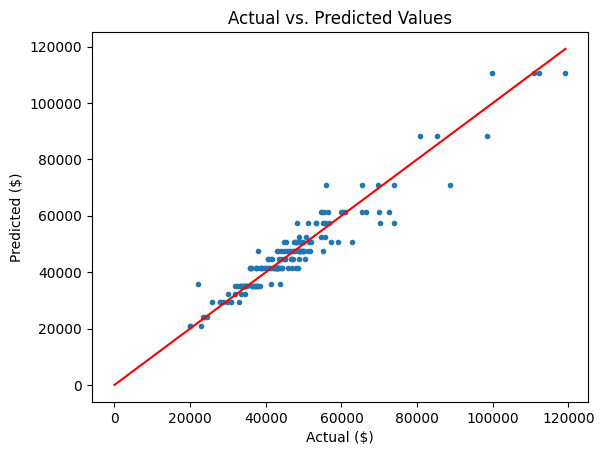

In [58]:
from pylab import *
scatter(x=y, # actual
        y=preds, # predicted
        marker=".")
title('Actual vs. Predicted Values')
xlabel('Actual ($)')
ylabel('Predicted ($)')
x = np.linspace(0, max(y))
plot(x, x, color='red') # a nice 45 degree line!
plt.show()

# How did the model make its decision?
Let's look at the rules!

## Tree visualization
How did our tree make its decision?

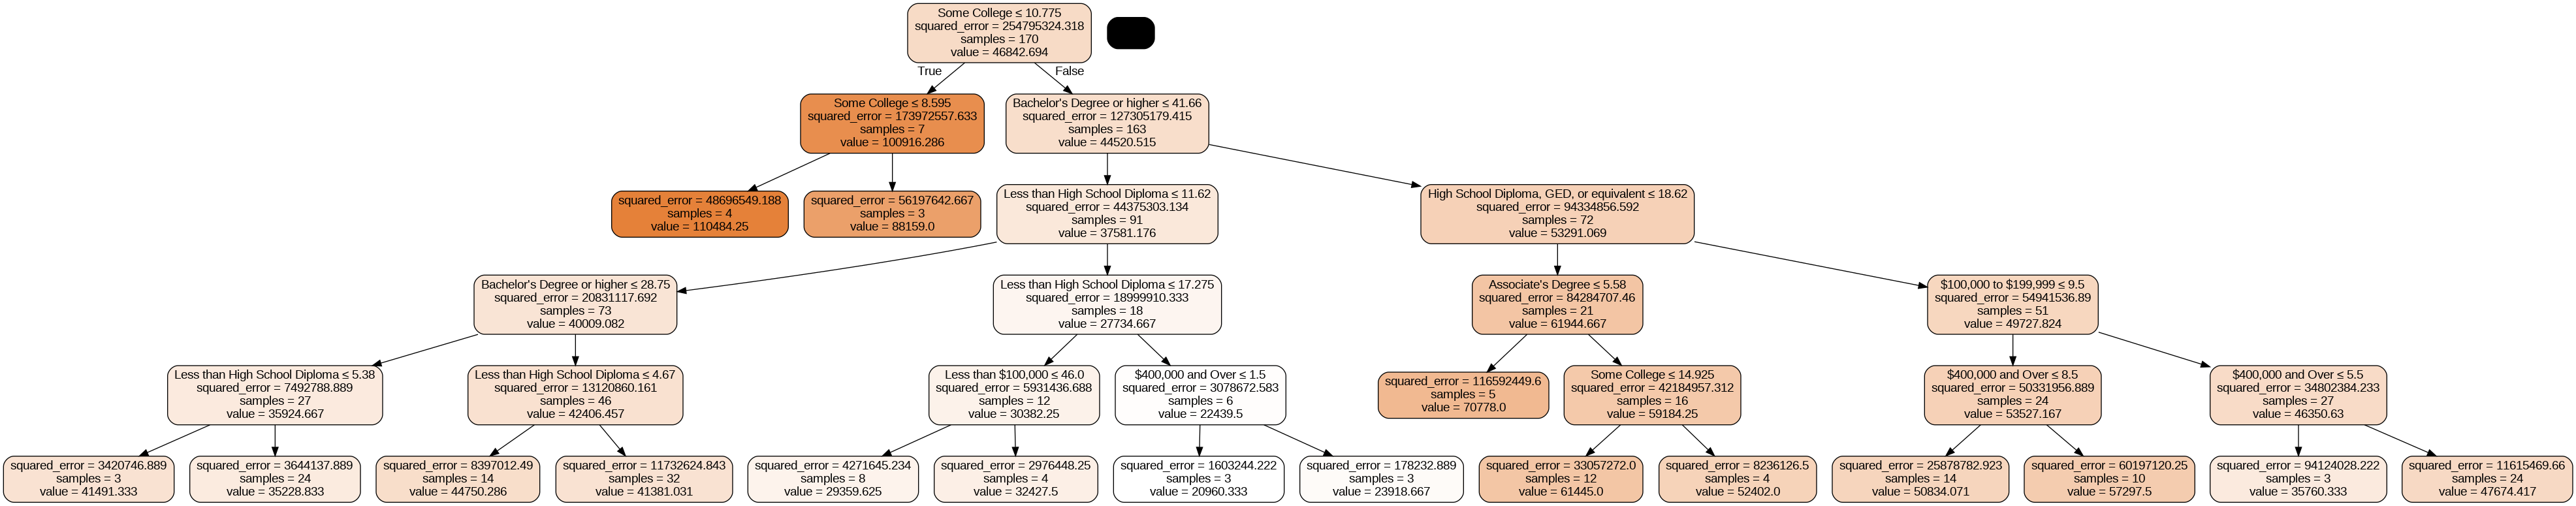

In [59]:

# show the tree
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(DTR, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                feature_names=X.columns)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

## Feature Importance
Which variables helped contribute to the prediction the most?

Permutation feature importance is a model inspection technique that can be used for any fitted estimator when the data is tabular. This is especially useful for non-linear or opaque estimators. The permutation feature importance is defined to be the decrease in a model score when a single feature value is randomly shuffled. This procedure breaks the relationship between the feature and the target, thus the drop in the model score is indicative of how much the model depends on the feature. This technique benefits from being model agnostic and can be calculated many times with different permutations of the feature.

In [60]:
from sklearn.inspection import permutation_importance
r = permutation_importance(DTR, X, y,
                           n_repeats=30,
                           random_state=0)

for i in r.importances_mean.argsort()[::-1]:
    if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
        print(f"{X.columns[i]:<8}"
              f"{r.importances_mean[i]:.3f}"
              f" +/- {r.importances_std[i]:.3f}")

Some College0.728 +/- 0.087
Bachelor's Degree or higher0.282 +/- 0.037
Less than High School Diploma0.104 +/- 0.012
$100,000 to $199,9990.072 +/- 0.015
High School Diploma, GED, or equivalent0.058 +/- 0.011
$400,000 and Over0.054 +/- 0.013
Associate's Degree0.021 +/- 0.006
Less than $100,0000.001 +/- 0.000


<ipython-input-61-ce70a6651c93>:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(X.columns[tree_importance_sorted_idx])


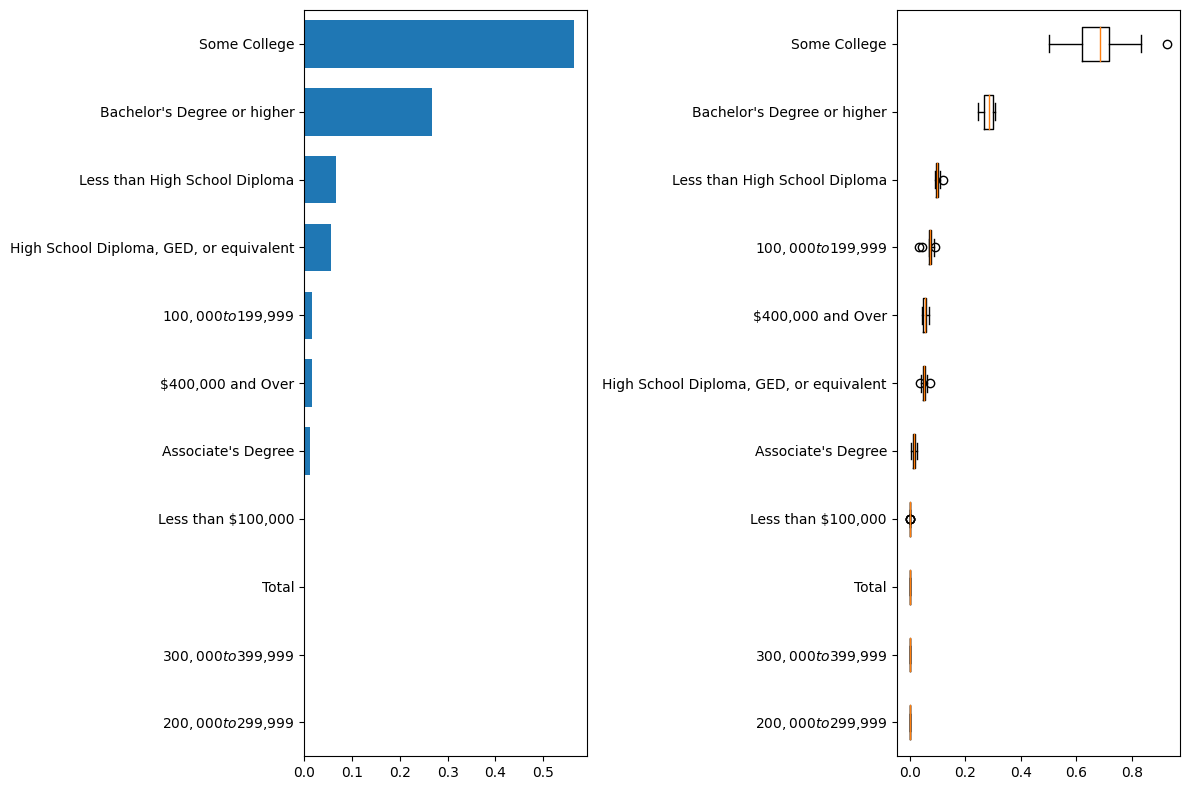

In [61]:
clf = DTR
result = permutation_importance(clf, X, y, n_repeats=10,
                                random_state=42)
perm_sorted_idx = result.importances_mean.argsort()

tree_importance_sorted_idx = np.argsort(clf.feature_importances_)
tree_indices = np.arange(0, len(clf.feature_importances_)) + 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
ax1.barh(tree_indices,
         clf.feature_importances_[tree_importance_sorted_idx], height=0.7)
ax1.set_yticklabels(X.columns[tree_importance_sorted_idx])
ax1.set_yticks(tree_indices)
ax1.set_ylim((0, len(clf.feature_importances_)))
ax2.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X.columns[perm_sorted_idx])
fig.tight_layout()
plt.show()

We can see that college is a better predictor of your income than the house prices!

What if we recoded house sales to a percentage instead of a number?

# Activity
Go on ctdata.org and think about some other models you can build - feel free to open in Excel to view the dataset! Who would your model be most valuable to?